Import Libraries

In [16]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2

from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras.applications import ResNet50V2
from tensorflow.keras.applications.resnet_v2 import preprocess_input
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.utils import to_categorical

In [17]:
# Parameters
NUM_BREEDS = 60
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 10

TRAIN_DIR = r"D:\Research Papers\DOG BREED IDENTIFICATION RESNET50\Dog-Breed-classification-main\train"
LABELS_CSV = r"D:\Research Papers\DOG BREED IDENTIFICATION RESNET50\Dog-Breed-classification-main\labels.csv"

In [18]:
# Load data
df = pd.read_csv(LABELS_CSV)

# Select top breeds
top_breeds = df['breed'].value_counts().index[:NUM_BREEDS]
df = df[df['breed'].isin(top_breeds)]

print("Total images:", len(df))

Total images: 5720


In [19]:
# Label encodeing
encoder = LabelEncoder()
df['label'] = encoder.fit_transform(df['breed'])

In [20]:
# Load Images
X = []
y = []

for i in range(len(df)):
    img_id = df.iloc[i]['id']
    label = df.iloc[i]['label']

    path = os.path.join(TRAIN_DIR, img_id + ".jpg")

    img = Image.open(path).convert('RGB')
    img = img.resize((IMG_SIZE, IMG_SIZE))
    img = np.array(img)

    X.append(img)
    y.append(label)

X = np.array(X, dtype='float32')
y = np.array(y)

# Preprocess
X = preprocess_input(X)

# One-hot
y = to_categorical(y, NUM_BREEDS)

In [21]:
# Train-Test Split
x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [22]:
# Build Model
base_model = ResNet50V2(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

# Freeze base model
for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = BatchNormalization()(x)
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)
x = Dropout(0.4)(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.3)(x)

output = Dense(NUM_BREEDS, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

In [23]:
# Compile Model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
# Train Model
history = model.fit(
    x_train, y_train,
    validation_data=(x_test, y_test),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE
)

Epoch 1/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 128s 837ms/step - accuracy: 0.2786 - loss: 3.3962 - val_accuracy: 0.6705 - val_loss: 2.1231
Epoch 2/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 116s 810ms/step - accuracy: 0.6772 - loss: 1.6139 - val_accuracy: 0.8164 - val_loss: 0.8987
Epoch 3/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 115s 803ms/step - accuracy: 0.7753 - loss: 0.9003 - val_accuracy: 0.8313 - val_loss: 0.6610
Epoch 4/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 114s 799ms/step - accuracy: 0.8073 - loss: 0.6841 - val_accuracy: 0.8339 - val_loss: 0.5795
Epoch 5/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 118s 823ms/step - accuracy: 0.8438 - loss: 0.5505 - val_accuracy: 0.8374 - val_loss: 0.5528
Epoch 6/10
101/143 ━━━━━━━━━━━━━━━━━━━━ 11:24 16s/step - accuracy: 0.8768 - loss: 0.4469

In [ ]:
# Evaluation
loss, acc = model.evaluate(x_test, y_test)
print("Final Test Accuracy:", acc * 100)

36/36 ━━━━━━━━━━━━━━━━━━━━ 24s 664ms/step - accuracy: 0.8497 - loss: 0.5215
Final Test Accuracy: 84.96503233909607


36/36 ━━━━━━━━━━━━━━━━━━━━ 27s 701ms/step


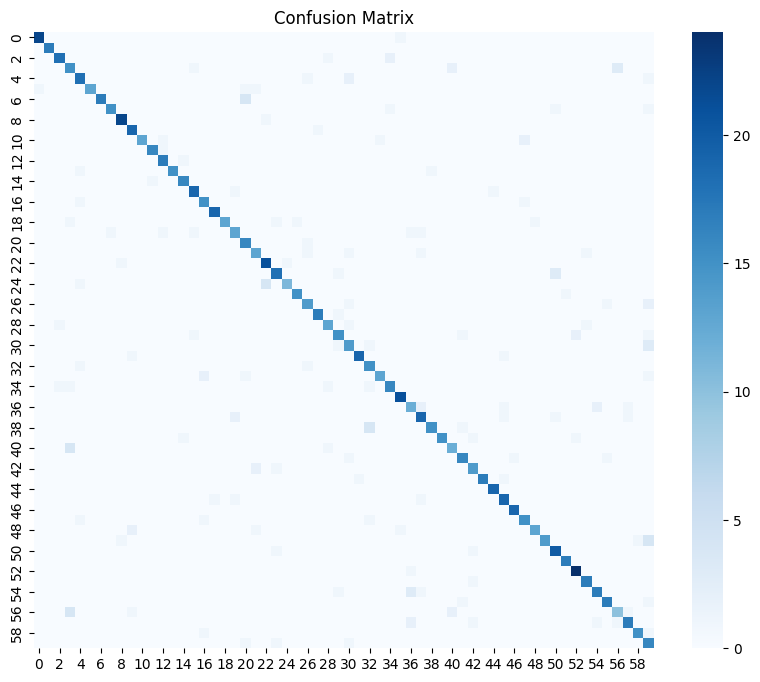

In [ ]:
# Confusion Matrix
y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred_classes)

import seaborn as sns
plt.figure(figsize=(10,8))
sns.heatmap(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
# Classification Report
print(classification_report(y_true, y_pred_classes))

              precision    recall  f1-score   support

           0       0.96      0.96      0.96        23
           1       1.00      1.00      1.00        17
           2       0.90      0.86      0.88        21
           3       0.60      0.71      0.65        21
           4       0.78      0.82      0.80        22
           5       1.00      0.81      0.90        16
           6       1.00      0.81      0.89        21
           7       0.94      0.83      0.88        18
           8       0.92      0.96      0.94        23
           9       0.83      0.95      0.88        20
          10       1.00      0.76      0.87        17
          11       0.94      0.94      0.94        17
          12       0.85      0.94      0.89        18
          13       1.00      0.88      0.94        17
          14       0.89      0.94      0.91        17
          15       0.86      0.90      0.88        21
          16       0.79      0.88      0.83        17
          17       0.95    

In [ ]:
# Sample Predictions
for i in range(5,10):
    # plt.imshow((x_test[i] + 1) * 127.5)  # reverse preprocess
    plt.imshow(x_test[i  1] *200)  # If original was [0, 255]
    pred = y_pred_classes[i]
    actual = y_true[i]

    plt.title(f"Pred: {encoder.inverse_transform([pred])[0]} | Actual: {encoder.inverse_transform([actual])[0]}")
    plt.axis('on')
    plt.grid(True)
    plt.show()

SyntaxError: invalid syntax. Perhaps you forgot a comma? (3558919663.py, line 4)

In [ ]:
# Save Model
model.save("dog_breed_model.keras")

In [ ]:
# Prediction function
def predict_image(img_path):
    img = Image.open(img_path).convert('RGB')
    img = img.resize((IMG_SIZE, IMG_SIZE))
    img = np.array(img)

    img = preprocess_input(img)
    img = np.expand_dims(img, axis=0)

    preds = model.predict(img)
    class_idx = np.argmax(preds)

    breed = encoder.inverse_transform([class_idx])[0]
    confidence = preds[0][class_idx]

    return breed, confidence

In [ ]:
# Test with a new image
# img_path = r"C:\Users\GOVIND MOHARIL\OneDrive\Desktop\DOG BREED CLASSIFICATION RESNET,VGG,GOOGLENET\images (1).jpg"
img_path = r"C:\Users\GOVIND MOHARIL\Downloads\img002.jpg"
img = Image.open(img_path)
img.show()
img = img.resize((IMG_SIZE, IMG_SIZE))
img_array = np.expand_dims(np.array(img).astype(np.float32), axis=0)
img_array = preprocess_input(img_array)

# Predict the breed probabilities and measure confidence
predictions = model.predict(img_array)
confidence = float(np.max(predictions))
confidence_pct = confidence * 100

# Show the breed only if prediction confidence crosses the threshold
confidence_threshold = 0.60
if confidence < confidence_threshold:
    print("Image is not a dog breed from this model or confidence is too low.")
    print(f"Top predicted confidence: {confidence_pct:.2f}%")
else:
    pred_label = np.argmax(predictions, axis=1)
    pred_breed = encoder.inverse_transform(pred_label)
    print(f"Predicted Breed for this Dog is: {pred_breed[0]} (confidence {confidence_pct:.2f}%)")




1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step
Predicted Breed for this Dog is: miniature_pinscher (confidence 97.03%)


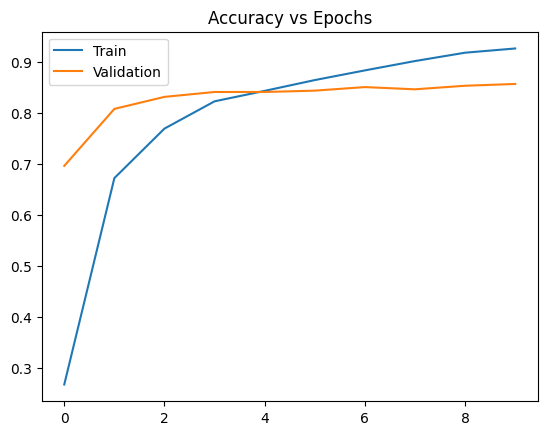

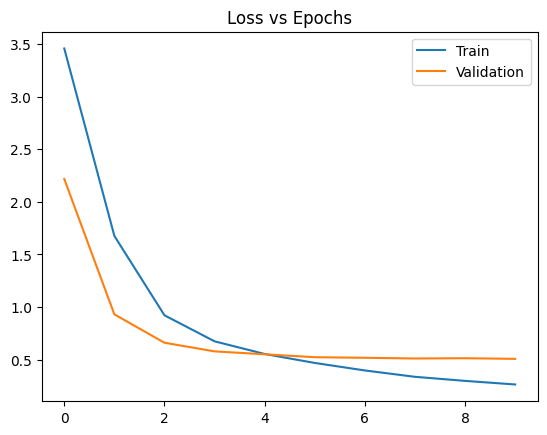

In [ ]:
# Plot Graphs
# Accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Accuracy vs Epochs")
plt.legend(["Train", "Validation"])
plt.show()

# Loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Loss vs Epochs")
plt.legend(["Train", "Validation"])
plt.show()

In [ ]:
from sklearn.metrics import classification_report, f1_score
import pandas as pd
import numpy as np

# Convert predictions
y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

# =========================
# 1. OVERALL F1 SCORE
# =========================
f1_macro = f1_score(y_true, y_pred_classes, average='macro')
f1_weighted = f1_score(y_true, y_pred_classes, average='weighted')

print("F1 Score (Macro):", round(f1_macro, 4))
print("F1 Score (Weighted):", round(f1_weighted, 4))

# =========================
# 2. PER-CLASS REPORT
# =========================
class_names = encoder.classes_

report = classification_report(
    y_true,
    y_pred_classes,
    target_names=class_names,
    output_dict=True
)

# Convert to DataFrame for better display
report_df = pd.DataFrame(report).transpose()

print("\nPer-Class Classification Report:")
print(report_df)

# Optional: Save report
report_df.to_csv("classification_report.csv")

NameError: name 'model' is not defined